In [1]:
import torch
import torch.nn as nn

Using: cpu


c:\Users\Manas\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")



─────────────────────────────────────────────
λ = 1e-05
─────────────────────────────────────────────
  Epoch 05 | loss 2873.32 | acc 55.2% | sparsity 0.0%
  Epoch 10 | loss 1857.74 | acc 56.2% | sparsity 1.5%
  Epoch 15 | loss 1389.72 | acc 55.9% | sparsity 12.6%
  Epoch 20 | loss 1098.89 | acc 56.2% | sparsity 20.3%

─────────────────────────────────────────────
λ = 0.0001
─────────────────────────────────────────────
  Epoch 05 | loss 10617.81 | acc 54.6% | sparsity 0.0%
  Epoch 10 | loss 3595.46 | acc 56.8% | sparsity 29.3%
  Epoch 15 | loss 2199.13 | acc 56.7% | sparsity 70.8%
  Epoch 20 | loss 1683.64 | acc 56.7% | sparsity 78.4%

─────────────────────────────────────────────
λ = 0.001
─────────────────────────────────────────────
  Epoch 05 | loss 86972.00 | acc 52.7% | sparsity 0.0%
  Epoch 10 | loss 15655.54 | acc 53.5% | sparsity 92.8%
  Epoch 15 | loss 4492.12 | acc 54.1% | sparsity 99.2%
  Epoch 20 | loss 2239.85 | acc 54.5% | sparsity 99.5%


Summary
λ            Accuracy

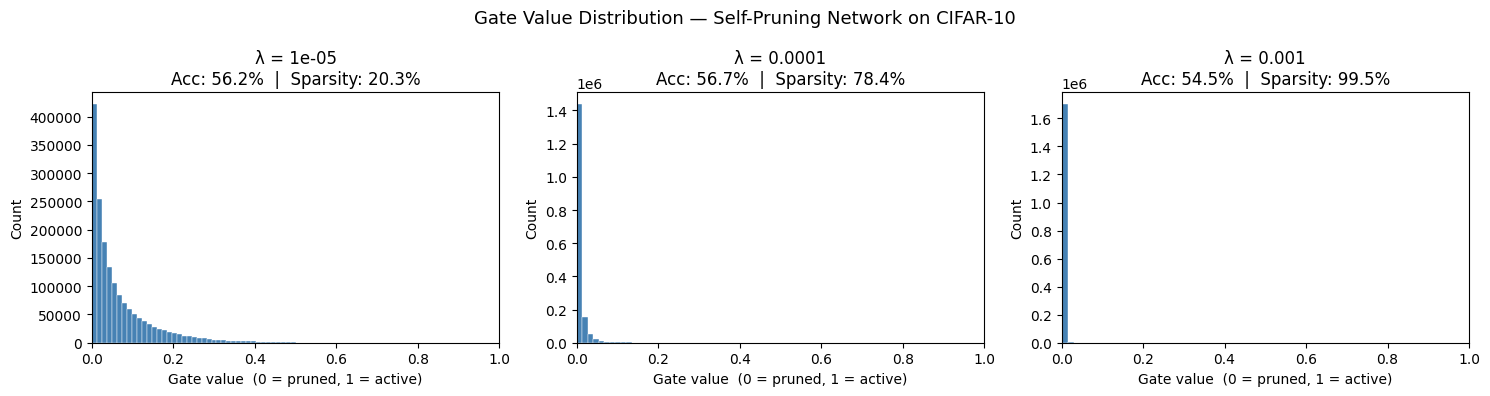


Plot saved → gate_distribution.png


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# ── Device ────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")


# ── PrunableLinear ────────────────────────────────────────────
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.weight      = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias        = nn.Parameter(torch.zeros(out_features))
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features) * 0.01)  
    def forward(self, x):
        gates          = torch.sigmoid(self.gate_scores)
        pruned_weights = self.weight * gates
        return torch.matmul(x, pruned_weights.t()) + self.bias

    def get_gates(self):
        return torch.sigmoid(self.gate_scores).detach()


# ── Model definition ───────────────────────────────────────────────
class PrunableNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = PrunableLinear(32 * 32 * 3, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

    def get_all_gates(self):
        gates = []
        for m in self.modules():
            if isinstance(m, PrunableLinear):
                gates.append(m.get_gates().flatten())
        return torch.cat(gates)


# ── Data loaders ──────────────────────────────────────────────
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(                             
        mean=(0.4914, 0.4822, 0.4465),
        std =(0.2023, 0.1994, 0.2010)
    )
])

trainset = torchvision.datasets.CIFAR10('./data', train=True,  download=True, transform=transform)
testset  = torchvision.datasets.CIFAR10('./data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader  = torch.utils.data.DataLoader(testset,  batch_size=64, shuffle=False)


# ── Helpers ───────────────────────────────────────────────────
def get_sparsity_loss(model):
    total = torch.tensor(0.0, device=device)
    for layer in model.modules():
        if isinstance(layer, PrunableLinear):
            total += torch.sigmoid(layer.gate_scores).sum()
    return total


def evaluate(model):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            preds    = model(images).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    return 100 * correct / total


def compute_sparsity(model, threshold=1e-2):
    gates = model.get_all_gates()
    return 100 * (gates < threshold).float().mean().item()


# ── Train one run ─────────────────────────────────────────────
def run(lam, epochs=20):
    print(f"\n{'─'*45}\nλ = {lam}\n{'─'*45}")
    model     = PrunableNet().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            out           = model(images)
            ce            = criterion(out, labels)
            sparse        = get_sparsity_loss(model)
            loss          = ce + lam * sparse
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        if epoch % 5 == 0:
            acc  = evaluate(model)
            spar = compute_sparsity(model)
            print(f"  Epoch {epoch:02d} | loss {epoch_loss:.2f} | acc {acc:.1f}% | sparsity {spar:.1f}%")

    return model.get_all_gates().cpu().numpy(), evaluate(model), compute_sparsity(model)



lambdas = [1e-5, 1e-4, 1e-3]
results = {}

for lam in lambdas:
    gates, acc, sparsity = run(lam)
    results[lam] = {"gates": gates, "acc": acc, "sparsity": sparsity}

# ── Summary table ─────────────────────────────────────────────
print("\n\nSummary")
print(f"{'λ':<10} {'Accuracy':>10} {'Sparsity':>10}")
print("─" * 32)
for lam in lambdas:
    r = results[lam]
    print(f"{lam:<10} {r['acc']:>9.2f}% {r['sparsity']:>9.1f}%")

# ── Gate distribution plot ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, lam in zip(axes, lambdas):
    r = results[lam]
    ax.hist(r["gates"], bins=60, color="steelblue", edgecolor="white", linewidth=0.3)
    ax.set_title(
        f"λ = {lam}\n"
        f"Acc: {r['acc']:.1f}%  |  Sparsity: {r['sparsity']:.1f}%"
    )
    ax.set_xlabel("Gate value  (0 = pruned, 1 = active)")
    ax.set_ylabel("Count")
    ax.set_xlim(0, 1)

plt.suptitle("Gate Value Distribution — Self-Pruning Network on CIFAR-10", fontsize=13)
plt.tight_layout()
plt.savefig("gate_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nPlot saved → gate_distribution.png")